In [9]:
%%writefile requirements.txt
numpy
matplotlib
gymnasium
torch
tensorboard
sb3-contrib
tqdm

Overwriting requirements.txt


In [10]:
!pip3 install -r requirements.txt

In [ ]:
%%writefile src/direct_guidance_fighter_env.py
from __future__ import annotations

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class DirectGuidanceFighterEnv(gym.Env):
    metadata = {"render_modes": []}

    MODE_RECOVER = 0
    MODE_EVADE = 1
    MODE_ATTACK = 2
    MODE_PURSUIT = 3
    NUM_MODES = 4

    def __init__(self):
        super().__init__()

        self.dt = 0.05
        self.max_steps = 1500
        self.g = 9.81

        self.min_combat_altitude = 25.0
        self.safe_altitude = 42.0

        self.damage_scale = 8.0

        # Gun / lead model
        self.projectile_speed = 95.0
        self.max_lead_time = 1.5
        self.gun_projectile_speed = 140.0
        self.gun_max_range = 100.0
        self.gun_strong_angle_deg = 6.0
        self.gun_weak_angle_deg = 12.0

        # Atmosphere
        self.rho0 = 1.225
        self.air_scale_height = 8500.0
        self.min_density_scale = 0.25

        # Aircraft approximate parameters
        self.mass = 1.0
        self.S = 0.8
        self.b = 2.5
        self.c = 0.9

        self.I = np.array([0.75, 1.20, 1.60], dtype=np.float32)
        self.I_inv = 1.0 / self.I

        self.max_thrust_accel = 44.0

        self.CD0 = 0.035
        self.K_drag = 0.055
        self.CL_alpha = 3.2
        self.CL_max = 1.25
        self.CY_beta = -0.9

        self.Cl_da = 0.85
        self.Cm_de = -1.20
        self.Cn_dr = 0.75

        self.roll_damp = 0.55
        self.pitch_damp = 0.70
        self.yaw_damp = 0.65

        self.max_omega = np.array([4.5, 3.5, 3.0], dtype=np.float32)

        # Action = [aileron, elevator, rudder, throttle]
        self.act_dim = 4
        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, -1.0, 0.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        # obs:
        # pos 3, vel 3, rpy 3, omega 3,
        # rel_pos 3, rel_vel 3,
        # my_fwd 3, enemy_fwd 3,
        # scalar 14
        self.base_obs_dim = 39
        self.obs_dim = self.base_obs_dim + self.NUM_MODES

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32,
        )

        self.reset()

    # ============================================================
    # Math utils
    # ============================================================

    def _normalize(self, v):
        n = np.linalg.norm(v)
        if n < 1e-6:
            return np.array([1.0, 0.0, 0.0], dtype=np.float32)
        return (v / n).astype(np.float32)

    def _skew(self, w):
        wx, wy, wz = w
        return np.array([
            [0.0, -wz, wy],
            [wz, 0.0, -wx],
            [-wy, wx, 0.0],
        ], dtype=np.float32)

    def _orthonormalize(self, R):
        U, _, Vt = np.linalg.svd(R)
        Rn = U @ Vt
        if np.linalg.det(Rn) < 0:
            U[:, -1] *= -1.0
            Rn = U @ Vt
        return Rn.astype(np.float32)

    def _rotation_from_rpy(self, roll, pitch, yaw):
        cp = np.cos(pitch)
        sp = np.sin(pitch)
        cy = np.cos(yaw)
        sy = np.sin(yaw)

        f = np.array([cp * cy, cp * sy, sp], dtype=np.float32)
        r0 = np.array([-sy, cy, 0.0], dtype=np.float32)
        u0 = self._normalize(np.cross(f, r0))

        cr = np.cos(roll)
        sr = np.sin(roll)

        r = self._normalize(cr * r0 + sr * u0)
        u = self._normalize(np.cross(f, r))

        return np.stack([f, r, u], axis=1).astype(np.float32)

    def _rpy_from_rotation(self, R):
        f = R[:, 0]
        r = R[:, 1]

        yaw = np.arctan2(f[1], f[0])
        pitch = np.arctan2(f[2], np.linalg.norm(f[:2]) + 1e-6)

        r0 = np.array([-np.sin(yaw), np.cos(yaw), 0.0], dtype=np.float32)
        cp = np.cos(pitch)
        sp = np.sin(pitch)
        cy = np.cos(yaw)
        sy = np.sin(yaw)
        f0 = np.array([cp * cy, cp * sy, sp], dtype=np.float32)
        u0 = self._normalize(np.cross(f0, r0))

        roll = np.arctan2(np.dot(r, u0), np.dot(r, r0))

        return np.array([roll, pitch, yaw], dtype=np.float32)

    def _air_density_scale(self, altitude):
        altitude = max(float(altitude), 0.0)
        rho_scale = np.exp(-altitude / self.air_scale_height)
        return float(np.clip(rho_scale, self.min_density_scale, 1.0))

    # ============================================================
    # State helpers
    # ============================================================

    def _sync_axes(self):
        self.forward_vec = np.stack([self.R[0, :, 0], self.R[1, :, 0]], axis=0).astype(np.float32)

    def _forward(self, i):
        return self.R[i, :, 0]

    def _right(self, i):
        return self.R[i, :, 1]

    def _up(self, i):
        return self.R[i, :, 2]

    def _speed(self, i):
        return float(np.linalg.norm(self.vel[i]))

    def _energy(self, i):
        height = max(float(self.pos[i, 2]), 0.0)
        speed = self._speed(i)
        return self.g * height + 0.5 * speed ** 2

    def _angle_deg_between(self, a, b):
        a = self._normalize(a)
        b = self._normalize(b)
        cos_theta = np.clip(np.dot(a, b), -1.0, 1.0)
        return float(np.degrees(np.arccos(cos_theta)))

    # ============================================================
    # Gym API
    # ============================================================

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.pos = np.array([
            [0.0, 0.0, 55.0],
            [95.0, 30.0, 55.0],
        ], dtype=np.float32)

        self.vel = np.array([
            [32.0, 0.0, 0.0],
            [-26.0, 0.0, 0.0],
        ], dtype=np.float32)

        self.R = np.zeros((2, 3, 3), dtype=np.float32)
        self.R[0] = self._rotation_from_rpy(0.0, 0.0, 0.0)
        self.R[1] = self._rotation_from_rpy(0.0, 0.0, np.pi)

        self.omega = np.zeros((2, 3), dtype=np.float32)

        self.pos += self.np_random.uniform(-5.0, 5.0, size=self.pos.shape).astype(np.float32)
        self.pos[:, 2] = np.clip(self.pos[:, 2], 45.0, 65.0)

        self.enemy_turn_dir = float(self.np_random.choice([-1.0, 1.0]))
        self.enemy_bt_mode = "pursuit"
        self.enemy_maneuver = "lead_pursuit"
        self.enemy_maneuver_steps = 0

        self.hp = np.array([100.0, 100.0], dtype=np.float32)
        self.step_count = 0
        self.current_mode = self.MODE_PURSUIT

        self._sync_axes()

        return self._get_obs(0), {}

    # ============================================================
    # Geometry / targeting
    # ============================================================

    def _los_angle_deg(self, shooter, target):
        rel = self.pos[target] - self.pos[shooter]
        dist = float(np.linalg.norm(rel))
        to_target = rel / (dist + 1e-6)
        theta = self._angle_deg_between(self._forward(shooter), to_target)
        return theta, dist

    def _los_rate(self, shooter, target):
        rel_pos = self.pos[target] - self.pos[shooter]
        rel_vel = self.vel[target] - self.vel[shooter]
        r2 = max(float(np.dot(rel_pos, rel_pos)), 1e-6)
        return float(np.linalg.norm(np.cross(rel_pos, rel_vel)) / r2)

    def _closure_rate(self, shooter, target):
        rel_pos = self.pos[target] - self.pos[shooter]
        rel_vel = self.vel[target] - self.vel[shooter]
        to_target = self._normalize(rel_pos)
        return float(-np.dot(rel_vel, to_target))

    def _lead_point(self, shooter, target):
        rel = self.pos[target] - self.pos[shooter]
        dist = float(np.linalg.norm(rel))
        t_go = dist / max(self.projectile_speed, 1.0)
        t_go = float(np.clip(t_go, 0.05, self.max_lead_time))
        return self.pos[target] + self.vel[target] * t_go

    def _lead_dir(self, shooter, target):
        return self._normalize(self._lead_point(shooter, target) - self.pos[shooter])

    def _lead_angle_deg(self, shooter, target):
        return self._angle_deg_between(self._forward(shooter), self._lead_dir(shooter, target))

    def _aspect_angle_deg(self, shooter, target):
        to_shooter = self._normalize(self.pos[shooter] - self.pos[target])
        return self._angle_deg_between(self._forward(target), to_shooter)

    def _tail_advantage_score(self, shooter, target):
        aspect = self._aspect_angle_deg(shooter, target)
        return float(np.clip((aspect - 90.0) / 90.0, 0.0, 1.0))

    def _gun_required_aim_dir(self, shooter, target):
        shooter_pos = self.pos[shooter]
        target_pos = self.pos[target]
        target_vel = self.vel[target]

        rel = target_pos - shooter_pos
        dist = float(np.linalg.norm(rel))

        t_go = dist / max(self.gun_projectile_speed, 1.0)
        gravity_vec = np.array([0.0, 0.0, -self.g], dtype=np.float32)

        for _ in range(3):
            target_future = target_pos + target_vel * t_go
            aim_vec = target_future - shooter_pos - 0.5 * gravity_vec * (t_go ** 2)
            t_go = float(np.linalg.norm(aim_vec) / max(self.gun_projectile_speed, 1.0))

        required_dir = self._normalize(aim_vec)
        return required_dir, t_go, dist

    def _gun_angle_deg(self, shooter, target):
        required_dir, t_go, dist = self._gun_required_aim_dir(shooter, target)
        gun_angle = self._angle_deg_between(self._forward(shooter), required_dir)
        return gun_angle, t_go, dist

    def _compute_gun_damage_rate(self, shooter, target):
        gun_angle_deg, _, dist = self._gun_angle_deg(shooter, target)

        if dist < 8.0 or dist > self.gun_max_range:
            return 0.0

        if gun_angle_deg > self.gun_weak_angle_deg:
            return 0.0

        range_center = 40.0
        range_width = self.gun_max_range - 8.0
        range_factor = 1.0 - abs(dist - range_center) / range_width
        range_factor = max(range_factor, 0.0)

        if gun_angle_deg <= self.gun_strong_angle_deg:
            angle_factor = 1.0 - gun_angle_deg / self.gun_strong_angle_deg
            return 1.6 * max(angle_factor, 0.0) * range_factor

        angle_factor = 1.0 - gun_angle_deg / self.gun_weak_angle_deg
        return 0.45 * max(angle_factor, 0.0) * range_factor

    def _is_enemy_behind(self, i, enemy):
        rel = self.pos[enemy] - self.pos[i]
        dist = np.linalg.norm(rel)
        to_enemy = rel / (dist + 1e-6)
        return float(np.dot(self._forward(i), to_enemy)) < -0.15

    def _enemy_on_my_six_score(self, i, enemy):
        rel = self.pos[enemy] - self.pos[i]
        dist = np.linalg.norm(rel)

        to_enemy = rel / (dist + 1e-6)
        to_me = -to_enemy

        enemy_behind_me = -np.dot(self._forward(i), to_enemy)
        enemy_aiming_me = np.dot(self._forward(enemy), to_me)

        return float(max(0.0, enemy_behind_me) * max(0.0, enemy_aiming_me))

    # ============================================================
    # Mode / observation
    # ============================================================

    def _select_mode(self):
        height = float(self.pos[0, 2])
        speed = self._speed(0)

        dist = float(np.linalg.norm(self.pos[1] - self.pos[0]))
        agent_los_deg, _ = self._los_angle_deg(0, 1)
        lead_angle_deg = self._lead_angle_deg(0, 1)

        enemy_behind = self._is_enemy_behind(0, 1)
        danger_score = self._enemy_on_my_six_score(0, 1)

        if height < self.safe_altitude + 8.0 or speed < 18.0:
            return self.MODE_RECOVER

        if enemy_behind and danger_score > 0.60:
            return self.MODE_EVADE

        if 8.0 < dist < 130.0 and (agent_los_deg < 75.0 or lead_angle_deg < 60.0):
            return self.MODE_ATTACK

        return self.MODE_PURSUIT

    def _mode_one_hot(self, mode):
        x = np.zeros(self.NUM_MODES, dtype=np.float32)
        x[mode] = 1.0
        return x

    def _get_base_obs(self, i):
        j = 1 - i

        rel_pos = self.pos[j] - self.pos[i]
        rel_vel = self.vel[j] - self.vel[i]

        my_speed = self._speed(i)
        enemy_speed = self._speed(j)
        my_energy = self._energy(i)
        enemy_energy = self._energy(j)

        dist = float(np.linalg.norm(rel_pos))
        los_rate = self._los_rate(i, j)
        aspect_angle = self._aspect_angle_deg(i, j)
        closure_rate = self._closure_rate(i, j)
        lead_angle = self._lead_angle_deg(i, j)
        tail_advantage = self._tail_advantage_score(i, j)
        energy_advantage = my_energy - enemy_energy
        altitude_error = self.pos[i, 2] - self.safe_altitude
        gun_angle, _, _ = self._gun_angle_deg(i, j)

        rpy = self._rpy_from_rotation(self.R[i])

        obs = np.concatenate([
            self.pos[i] / 100.0,
            self.vel[i] / 100.0,
            rpy,
            self.omega[i] / 5.0,
            rel_pos / 100.0,
            rel_vel / 100.0,
            self._forward(i),
            self._forward(j),
            np.array([
                my_speed / 100.0,
                my_energy / 5000.0,
                enemy_speed / 100.0,
                enemy_energy / 5000.0,
                self.hp[i] / 100.0,
                self.hp[j] / 100.0,
                dist / 150.0,
                los_rate * 10.0,
                aspect_angle / 180.0,
                closure_rate / 100.0,
                lead_angle / 180.0,
                gun_angle / 180.0,
                tail_advantage,
                energy_advantage / 5000.0,
                altitude_error / 50.0,
            ], dtype=np.float32),
        ])

        return obs.astype(np.float32)

    def _get_obs(self, i):
        if i == 0:
            self.current_mode = self._select_mode()
            mode_one_hot = self._mode_one_hot(self.current_mode)
        else:
            mode_one_hot = self._mode_one_hot(self.MODE_PURSUIT)

        return np.concatenate([self._get_base_obs(i), mode_one_hot]).astype(np.float32)

    # ============================================================
    # 6DoF dynamics
    # ============================================================

    def _sixdof_step(self, i, control):
        aileron = float(np.clip(control[0], -1.0, 1.0))
        elevator = float(np.clip(control[1], -1.0, 1.0))
        rudder = float(np.clip(control[2], -1.0, 1.0))
        throttle = float(np.clip(control[3], 0.0, 1.0))

        R = self.R[i]
        v_world = self.vel[i]
        v_body = R.T @ v_world

        speed = float(np.linalg.norm(v_world))
        speed_safe = max(speed, 1.0)

        vx = max(v_body[0], 1.0)
        alpha = float(np.arctan2(v_body[2], vx))
        beta = float(np.arctan2(v_body[1], vx))

        alpha = float(np.clip(alpha, -0.45, 0.45))
        beta = float(np.clip(beta, -0.45, 0.45))

        rho_scale = self._air_density_scale(self.pos[i, 2])
        qbar = 0.5 * self.rho0 * rho_scale * speed_safe ** 2

        CL = np.clip(self.CL_alpha * alpha, -self.CL_max, self.CL_max)
        CD = self.CD0 + self.K_drag * CL ** 2
        CY = self.CY_beta * beta

        fwd = R[:, 0]
        right = R[:, 1]
        up = R[:, 2]

        drag_force = -CD * qbar * self.S * self._normalize(v_world)
        lift_force = CL * qbar * self.S * up
        side_force = CY * qbar * self.S * right

        thrust_factor = 0.90 + 0.10 * rho_scale
        thrust_force = fwd * throttle * self.max_thrust_accel * thrust_factor

        gravity_force = np.array([0.0, 0.0, -self.g], dtype=np.float32)

        accel = thrust_force + drag_force + lift_force + side_force + gravity_force

        self.vel[i] = self.vel[i] + accel.astype(np.float32) * self.dt
        self.pos[i] = self.pos[i] + self.vel[i] * self.dt

        p, q, r = self.omega[i]

        roll_moment = (
            self.Cl_da * aileron * qbar * self.S * self.b
            - self.roll_damp * p * qbar * self.S * self.b * 0.08
        )

        pitch_moment = (
            self.Cm_de * elevator * qbar * self.S * self.c
            - self.pitch_damp * q * qbar * self.S * self.c * 0.08
        )

        yaw_moment = (
            self.Cn_dr * rudder * qbar * self.S * self.b
            - self.yaw_damp * r * qbar * self.S * self.b * 0.08
        )

        moment = np.array([roll_moment, pitch_moment, yaw_moment], dtype=np.float32)

        omega = self.omega[i]
        Iomega = self.I * omega
        gyro = np.cross(omega, Iomega)
        omega_dot = self.I_inv * (moment - gyro)

        self.omega[i] = self.omega[i] + omega_dot.astype(np.float32) * self.dt
        self.omega[i] = np.clip(self.omega[i], -self.max_omega, self.max_omega)

        self.R[i] = self.R[i] + (self.R[i] @ self._skew(self.omega[i])) * self.dt
        self.R[i] = self._orthonormalize(self.R[i])

        if self.pos[i, 2] < 5.0:
            self.pos[i, 2] = 5.0
            if self.vel[i, 2] < 0.0:
                self.vel[i, 2] = 0.0

    # ============================================================
    # Guidance autopilot
    # ============================================================

    def _guidance_to_controls(self, i, desired_dir, throttle):
        desired_dir = self._normalize(desired_dir)

        desired_body = self.R[i].T @ desired_dir
        desired_body = self._normalize(desired_body)

        yaw_err = np.arctan2(desired_body[1], desired_body[0])
        pitch_err = np.arctan2(desired_body[2], desired_body[0])

        p, q, r = self.omega[i]

        roll_target = np.clip(-2.0 * yaw_err, -1.0, 1.0)

        aileron = np.clip(1.5 * roll_target - 0.35 * p, -1.0, 1.0)
        elevator = np.clip(2.2 * pitch_err + 0.25 * q, -1.0, 1.0)
        rudder = np.clip(0.8 * yaw_err - 0.25 * r, -1.0, 1.0)

        return np.array([aileron, elevator, rudder, throttle], dtype=np.float32)

    def _blend_action_with_guidance(self, i, action):
        j = 1 - i

        action = np.asarray(action, dtype=np.float32)
        raw_control = np.array([
            np.clip(action[0], -1.0, 1.0),
            np.clip(action[1], -1.0, 1.0),
            np.clip(action[2], -1.0, 1.0),
            np.clip(action[3], 0.0, 1.0),
        ], dtype=np.float32)

        lead_dir = self._lead_dir(i, j)
        pure_dir = self._normalize(self.pos[j] - self.pos[i])

        dist = float(np.linalg.norm(self.pos[j] - self.pos[i]))
        danger = self._enemy_on_my_six_score(i, j)
        height = float(self.pos[i, 2])
        speed = self._speed(i)

        if height < self.safe_altitude + 8.0 or speed < 18.0:
            f = self._forward(i)
            guidance_dir = self._normalize(np.array([f[0], f[1], 0.8], dtype=np.float32))
            throttle = 1.0
            blend = 0.85

        elif danger > 0.65:
            away = self._normalize(self.pos[i] - self.pos[j])
            side = self._normalize(np.cross(np.array([0.0, 0.0, 1.0], dtype=np.float32), away))
            guidance_dir = self._normalize(
                0.60 * away + 0.45 * side + np.array([0.0, 0.0, 0.25], dtype=np.float32)
            )
            throttle = max(float(raw_control[3]), 0.9)
            blend = 0.70

        else:
            lead_weight = float(np.clip((150.0 - dist) / 130.0, 0.25, 0.85))
            guidance_dir = self._normalize(lead_weight * lead_dir + (1.0 - lead_weight) * pure_dir)
            throttle = float(raw_control[3])
            blend = 0.55

        guidance_control = self._guidance_to_controls(i, guidance_dir, throttle)

        control = (1.0 - blend) * raw_control + blend * guidance_control
        control[:3] = np.clip(control[:3], -1.0, 1.0)
        control[3] = np.clip(control[3], 0.0, 1.0)

        return control.astype(np.float32)

    # ============================================================
    # Enemy BT
    # ============================================================

    def _choose_enemy_maneuver(self):
        maneuvers = [
            "lead_pursuit",
            "hard_break_left",
            "hard_break_right",
            "high_yoyo",
            "low_yoyo",
            "scissors",
            "extend",
        ]

        probs = np.array([0.30, 0.15, 0.15, 0.14, 0.10, 0.10, 0.06], dtype=np.float32)
        probs = probs / probs.sum()

        self.enemy_maneuver = str(self.np_random.choice(maneuvers, p=probs))
        self.enemy_maneuver_steps = int(self.np_random.integers(18, 55))

    def _enemy_bt_action(self):
        i = 1
        target = 0

        rel = self.pos[target] - self.pos[i]
        dist = float(np.linalg.norm(rel))
        to_agent = self._normalize(rel)

        height = float(self.pos[i, 2])
        speed = self._speed(i)

        enemy_los_deg, _ = self._los_angle_deg(i, target)
        agent_los_deg, _ = self._los_angle_deg(target, i)

        danger_score = self._enemy_on_my_six_score(i, target)
        agent_aspect = self._aspect_angle_deg(target, i)

        if height < self.safe_altitude + 8.0 or speed < 18.0:
            self.enemy_bt_mode = "recover"
            f = self._forward(i)
            desired_dir = self._normalize(np.array([f[0], f[1], 0.8], dtype=np.float32))
            return self._guidance_to_controls(i, desired_dir, 1.0)

        agent_has_tail = (
            agent_los_deg < 35.0
            and 8.0 < dist < 140.0
            and agent_aspect > 100.0
        )

        if danger_score > 0.45 or agent_has_tail:
            self.enemy_bt_mode = "defensive"

            away = self._normalize(self.pos[i] - self.pos[target])
            side = self._normalize(np.cross(np.array([0.0, 0.0, 1.0], dtype=np.float32), away))

            if self.enemy_maneuver_steps <= 0:
                self.enemy_turn_dir = float(self.np_random.choice([-1.0, 1.0]))
                self.enemy_maneuver_steps = int(self.np_random.integers(20, 45))

            self.enemy_maneuver_steps -= 1

            vertical = 0.25
            if height < self.safe_altitude + 18.0:
                vertical = 0.50

            desired_dir = self._normalize(
                0.35 * away
                + 0.85 * self.enemy_turn_dir * side
                + np.array([0.0, 0.0, vertical], dtype=np.float32)
            )

            return self._guidance_to_controls(i, desired_dir, 1.0)

        if 8.0 < dist < 130.0 and enemy_los_deg < 70.0:
            self.enemy_bt_mode = "attack"
            lead_dir = self._lead_dir(i, target)
            desired_dir = self._normalize(0.85 * lead_dir + 0.15 * to_agent)
            return self._guidance_to_controls(i, desired_dir, 0.85)

        if self.enemy_maneuver_steps <= 0:
            self._choose_enemy_maneuver()

        self.enemy_maneuver_steps -= 1
        self.enemy_bt_mode = self.enemy_maneuver

        lead_dir = self._lead_dir(i, target)
        f = self._forward(i)
        side = self._normalize(np.cross(np.array([0.0, 0.0, 1.0], dtype=np.float32), to_agent))

        throttle = 0.8

        if self.enemy_maneuver == "lead_pursuit":
            desired_dir = self._normalize(0.80 * lead_dir + 0.20 * to_agent)
            throttle = 0.85

        elif self.enemy_maneuver == "hard_break_left":
            desired_dir = self._normalize(
                0.25 * to_agent + 0.95 * side + np.array([0.0, 0.0, 0.10], dtype=np.float32)
            )
            throttle = 1.0

        elif self.enemy_maneuver == "hard_break_right":
            desired_dir = self._normalize(
                0.25 * to_agent - 0.95 * side + np.array([0.0, 0.0, 0.10], dtype=np.float32)
            )
            throttle = 1.0

        elif self.enemy_maneuver == "high_yoyo":
            desired_dir = self._normalize(
                0.70 * lead_dir
                + 0.25 * side * self.enemy_turn_dir
                + np.array([0.0, 0.0, 0.55], dtype=np.float32)
            )
            throttle = 0.90

        elif self.enemy_maneuver == "low_yoyo":
            desired_z = -0.20 if height > self.safe_altitude + 25.0 else 0.20
            desired_dir = self._normalize(
                0.75 * lead_dir
                + 0.25 * side * self.enemy_turn_dir
                + np.array([0.0, 0.0, desired_z], dtype=np.float32)
            )
            throttle = 1.0

        elif self.enemy_maneuver == "scissors":
            phase = 1.0 if (self.step_count // 20) % 2 == 0 else -1.0
            desired_dir = self._normalize(
                0.35 * f
                + 0.90 * phase * side
                + np.array([0.0, 0.0, 0.10], dtype=np.float32)
            )
            throttle = 0.65

        elif self.enemy_maneuver == "extend":
            away = self._normalize(self.pos[i] - self.pos[target])
            desired_dir = self._normalize(
                0.75 * away + 0.25 * f + np.array([0.0, 0.0, 0.15], dtype=np.float32)
            )
            throttle = 1.0

        else:
            desired_dir = lead_dir
            throttle = 0.8

        if height < self.safe_altitude + 10.0:
            desired_dir[2] = max(desired_dir[2], 0.4)
            throttle = max(throttle, 0.95)

        if height > 140.0:
            desired_dir[2] = min(desired_dir[2], -0.15)

        desired_dir = self._normalize(desired_dir)
        return self._guidance_to_controls(i, desired_dir, throttle)

    # ============================================================
    # Reward
    # ============================================================

    def _mode_reward(
        self,
        mode,
        dist,
        progress,
        heading_align,
        closing_speed,
        agent_los_deg,
        agent_lead_deg,
        agent_aspect_deg,
        agent_gun_angle_deg,
        los_rate,
        enemy_damage_rate,
        agent_damage_rate,
        height,
        speed,
        danger_score,
        enemy_behind_agent,
    ):
        reward = 0.0

        los_reward = max(0.0, 1.0 - agent_los_deg / 70.0)
        lead_reward = max(0.0, 1.0 - agent_lead_deg / 55.0)
        gun_reward = max(0.0, 1.0 - agent_gun_angle_deg / self.gun_weak_angle_deg)
        aspect_reward = max(0.0, (agent_aspect_deg - 80.0) / 100.0)
        stable_los_reward = max(0.0, 1.0 - los_rate * 8.0)

        if mode == self.MODE_RECOVER:
            reward -= 1.0 * abs(height - self.safe_altitude)

            if height >= self.safe_altitude:
                reward += 18.0
            if height >= self.safe_altitude + 10.0:
                reward += 8.0
            if 26.0 < speed < 105.0:
                reward += 3.0

            reward -= 80.0 * enemy_damage_rate

        elif mode == self.MODE_EVADE:
            reward += 5.0 * danger_score

            if enemy_behind_agent and progress < 0.0:
                reward += 5.0 * (-progress)

            reward -= 130.0 * enemy_damage_rate

            if height >= self.safe_altitude:
                reward += 8.0

            if 32.0 < speed < 115.0:
                reward += 1.0

        elif mode == self.MODE_ATTACK:
            reward += 260.0 * agent_damage_rate
            reward -= 140.0 * enemy_damage_rate

            reward += 5.0 * heading_align
            reward += 5.0 * los_reward
            reward += 10.0 * lead_reward
            reward += 6.0 * gun_reward
            reward += 8.0 * aspect_reward
            reward += 4.0 * stable_los_reward
            reward += 2.0 * progress

            if agent_gun_angle_deg < self.gun_weak_angle_deg and 8.0 < dist < self.gun_max_range:
                reward += 8.0

            if agent_gun_angle_deg < self.gun_strong_angle_deg and 12.0 < dist < 70.0:
                reward += 18.0

            if agent_aspect_deg > 110.0 and 8.0 < dist < 100.0:
                reward += 8.0

            if dist < 6.0:
                reward -= 10.0

        elif mode == self.MODE_PURSUIT:
            reward += 5.0 * heading_align
            reward += 5.0 * los_reward
            reward += 9.0 * lead_reward
            reward += 4.0 * gun_reward
            reward += 6.0 * aspect_reward
            reward += 4.0 * stable_los_reward
            reward += 5.0 * progress
            reward += 0.04 * closing_speed
            reward -= 0.016 * dist

            if 18.0 < dist < 110.0:
                reward += 2.0

            reward += 95.0 * agent_damage_rate
            reward -= 95.0 * enemy_damage_rate

        return reward

    # ============================================================
    # Step
    # ============================================================

    def step(self, action):
        mode = self._select_mode()
        self.current_mode = mode

        agent_raw_action = np.asarray(action, dtype=np.float32)
        agent_control = self._blend_action_with_guidance(0, agent_raw_action)
        enemy_control = self._enemy_bt_action()

        prev_dist = float(np.linalg.norm(self.pos[1] - self.pos[0]))

        self._sixdof_step(0, agent_control)
        self._sixdof_step(1, enemy_control)
        self._sync_axes()

        self.step_count += 1

        dist = float(np.linalg.norm(self.pos[1] - self.pos[0]))
        progress = prev_dist - dist

        agent_los_deg, _ = self._los_angle_deg(0, 1)
        enemy_los_deg, _ = self._los_angle_deg(1, 0)

        agent_lead_deg = self._lead_angle_deg(0, 1)
        enemy_lead_deg = self._lead_angle_deg(1, 0)

        agent_aspect_deg = self._aspect_angle_deg(0, 1)
        enemy_aspect_deg = self._aspect_angle_deg(1, 0)

        los_rate = self._los_rate(0, 1)
        closure_rate = self._closure_rate(0, 1)

        agent_gun_angle_deg, agent_bullet_tgo, agent_gun_dist = self._gun_angle_deg(0, 1)
        enemy_gun_angle_deg, enemy_bullet_tgo, enemy_gun_dist = self._gun_angle_deg(1, 0)

        agent_damage_rate = self._compute_gun_damage_rate(0, 1)
        enemy_damage_rate = self._compute_gun_damage_rate(1, 0)

        agent_damage_to_hp = agent_damage_rate * self.damage_scale
        enemy_damage_to_hp = enemy_damage_rate * self.damage_scale

        self.hp[1] -= agent_damage_to_hp
        self.hp[0] -= enemy_damage_to_hp
        self.hp = np.clip(self.hp, 0.0, 100.0)

        speed = self._speed(0)
        height = float(self.pos[0, 2])
        enemy_height = float(self.pos[1, 2])

        rel = self.pos[1] - self.pos[0]
        to_enemy = rel / (np.linalg.norm(rel) + 1e-6)

        heading_align = float(np.dot(self._forward(0), to_enemy))
        closing_speed = float(np.dot(self.vel[0], to_enemy))

        enemy_behind_agent = self._is_enemy_behind(0, 1)
        danger_score = self._enemy_on_my_six_score(0, 1)

        reward = self._mode_reward(
            mode=mode,
            dist=dist,
            progress=progress,
            heading_align=heading_align,
            closing_speed=closing_speed,
            agent_los_deg=agent_los_deg,
            agent_lead_deg=agent_lead_deg,
            agent_aspect_deg=agent_aspect_deg,
            agent_gun_angle_deg=agent_gun_angle_deg,
            los_rate=los_rate,
            enemy_damage_rate=enemy_damage_rate,
            agent_damage_rate=agent_damage_rate,
            height=height,
            speed=speed,
            danger_score=danger_score,
            enemy_behind_agent=enemy_behind_agent,
        )

        vertical_speed = float(self.vel[0, 2])
        agent_energy = self._energy(0)
        enemy_energy = self._energy(1)
        energy_advantage = agent_energy - enemy_energy

        altitude_error = max(0.0, self.safe_altitude - height)
        reward -= 8.0 * altitude_error

        if height >= self.safe_altitude:
            reward += 4.0

        if height < self.min_combat_altitude + 5.0:
            reward -= 100.0

        if vertical_speed < -8.0:
            reward -= 1.0 * abs(vertical_speed)

        if 24.0 <= speed <= 115.0:
            reward += 2.0
        elif speed < 16.0:
            reward -= 14.0
        elif speed > 180.0:
            reward -= 8.0

        if energy_advantage > -1000.0:
            reward += 0.5
        else:
            reward -= 0.0008 * abs(energy_advantage + 1000.0)

        reward -= 0.02

        terminated = False
        truncated = False

        if self.hp[1] <= 0.0:
            reward += 300.0
            terminated = True

        if self.hp[0] <= 0.0:
            reward -= 300.0
            terminated = True

        if height < self.min_combat_altitude:
            reward -= 300.0
            terminated = True

        if enemy_height < self.min_combat_altitude:
            reward += 300.0
            terminated = True

        if self.step_count >= self.max_steps:
            truncated = True

        info = {
            "mode": int(mode),
            "enemy_bt_mode": self.enemy_bt_mode,
            "enemy_maneuver": self.enemy_maneuver,
            "dist": dist,
            "agent_hp": float(self.hp[0]),
            "enemy_hp": float(self.hp[1]),
            "agent_damage_rate": float(agent_damage_rate),
            "enemy_damage_rate": float(enemy_damage_rate),
            "agent_damage_to_hp": float(agent_damage_to_hp),
            "enemy_damage_to_hp": float(enemy_damage_to_hp),
            "agent_damage": float(agent_damage_rate),
            "enemy_damage": float(enemy_damage_rate),
            "agent_los_deg": float(agent_los_deg),
            "enemy_los_deg": float(enemy_los_deg),
            "agent_lead_deg": float(agent_lead_deg),
            "enemy_lead_deg": float(enemy_lead_deg),
            "agent_gun_angle_deg": float(agent_gun_angle_deg),
            "enemy_gun_angle_deg": float(enemy_gun_angle_deg),
            "agent_bullet_tgo": float(agent_bullet_tgo),
            "enemy_bullet_tgo": float(enemy_bullet_tgo),
            "agent_gun_dist": float(agent_gun_dist),
            "enemy_gun_dist": float(enemy_gun_dist),
            "agent_aspect_deg": float(agent_aspect_deg),
            "enemy_aspect_deg": float(enemy_aspect_deg),
            "los_rate": float(los_rate),
            "closure_rate": float(closure_rate),
            "agent_energy": float(agent_energy),
            "enemy_energy": float(enemy_energy),
            "energy_advantage": float(energy_advantage),
            "agent_speed": float(speed),
            "enemy_speed": float(self._speed(1)),
            "agent_air_density_scale": float(self._air_density_scale(self.pos[0, 2])),
            "enemy_air_density_scale": float(self._air_density_scale(self.pos[1, 2])),
            "agent_pos": self.pos[0].copy(),
            "enemy_pos": self.pos[1].copy(),
            "agent_action": agent_raw_action.copy(),
            "agent_control": agent_control.copy(),
            "enemy_action": enemy_control.copy(),
            "danger_score": float(danger_score),
            "agent_vertical_speed": vertical_speed,
            "agent_altitude": float(height),
            "enemy_altitude": float(enemy_height),
            "agent_rpy": self._rpy_from_rotation(self.R[0]).copy(),
            "enemy_rpy": self._rpy_from_rotation(self.R[1]).copy(),
            "agent_omega": self.omega[0].copy(),
            "enemy_omega": self.omega[1].copy(),
            "min_combat_altitude": float(self.min_combat_altitude),
            "safe_altitude": float(self.safe_altitude),
        }

        return self._get_obs(0), float(reward), terminated, truncated, info

Overwriting src/direct_guidance_fighter_env.py


In [13]:
import os
import importlib
import torch

from tqdm.auto import tqdm

from sb3_contrib import RecurrentPPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv, VecMonitor

import src.direct_guidance_fighter_env as fighter_env

importlib.reload(fighter_env)
DirectGuidanceFighterEnv = fighter_env.DirectGuidanceFighterEnv


class TQDMProgressBarCallback(BaseCallback):
    def __init__(self, total_timesteps: int, update_freq: int = 4096):
        super().__init__()
        self.total_timesteps = total_timesteps
        self.update_freq = update_freq
        self.pbar = None

    def _on_training_start(self):
        self.pbar = tqdm(
            total=self.total_timesteps,
            desc="Training",
            dynamic_ncols=True,
        )

    def _on_step(self):
        if self.num_timesteps % self.update_freq != 0 and self.num_timesteps < self.total_timesteps:
            return True

        self.pbar.n = min(self.num_timesteps, self.total_timesteps)

        if len(self.model.ep_info_buffer) > 0:
            ep_rew_mean = sum(e["r"] for e in self.model.ep_info_buffer) / len(self.model.ep_info_buffer)
            ep_len_mean = sum(e["l"] for e in self.model.ep_info_buffer) / len(self.model.ep_info_buffer)

            self.pbar.set_postfix({
                "reward": f"{ep_rew_mean:.1f}",
                "len": f"{ep_len_mean:.0f}",
            })

        self.pbar.refresh()
        return True

    def _on_training_end(self):
        if self.pbar is not None:
            self.pbar.n = self.total_timesteps
            self.pbar.refresh()
            self.pbar.close()


def make_env(seed: int):
    def _init():
        env = DirectGuidanceFighterEnv()
        obs, _ = env.reset(seed=seed)

        assert obs.shape == env.observation_space.shape, (
            f"obs shape mismatch: obs={obs.shape}, "
            f"space={env.observation_space.shape}"
        )

        return Monitor(env)

    return _init


# =========================
# Sanity check
# =========================
test_env = DirectGuidanceFighterEnv()
test_obs, _ = test_env.reset()

print("obs shape     :", test_obs.shape)
print("declared shape:", test_env.observation_space.shape)

assert test_obs.shape == test_env.observation_space.shape, (
    f"obs shape mismatch: obs={test_obs.shape}, "
    f"space={test_env.observation_space.shape}"
)

test_env.close()


# =========================
# Train config
# =========================
os.makedirs("models", exist_ok=True)
os.makedirs("logs/recurrent_ppo_6dof", exist_ok=True)
os.makedirs("checkpoints/recurrent_ppo_6dof", exist_ok=True)

N_ENVS = 8
TOTAL_TIMESTEPS = 1_500_000
USE_SUBPROC = True

if USE_SUBPROC:
    env = SubprocVecEnv([make_env(i) for i in range(N_ENVS)])
else:
    env = DummyVecEnv([make_env(i) for i in range(N_ENVS)])

env = VecMonitor(env)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


# =========================
# Model
# =========================
model = RecurrentPPO(
    policy="MlpLstmPolicy",
    env=env,
    device=device,
    verbose=0,

    learning_rate=2e-4,

    n_steps=1024,
    batch_size=1024,
    n_epochs=8,

    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.2,

    ent_coef=0.03,
    vf_coef=0.7,
    max_grad_norm=0.5,

    tensorboard_log="logs/recurrent_ppo_6dof",

    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=False,
        enable_critic_lstm=True,
        net_arch=dict(
            pi=[128, 128],
            vf=[128, 128],
        ),
        activation_fn=torch.nn.Tanh,
    ),
)


# =========================
# Callbacks
# =========================
progress_callback = TQDMProgressBarCallback(
    total_timesteps=TOTAL_TIMESTEPS,
    update_freq=4096,
)

checkpoint_callback = CheckpointCallback(
    save_freq=100_000 // N_ENVS,
    save_path="checkpoints/recurrent_ppo_6dof",
    name_prefix="ppo_6dof",
    save_replay_buffer=False,
    save_vecnormalize=False,
)


# =========================
# Learn
# =========================
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[progress_callback, checkpoint_callback],
)

model.save("models/recurrent_ppo_6dof")

env.close()

print("saved: models/recurrent_ppo_6dof.zip")

obs shape     : (43,)
declared shape: (42,)


AssertionError: obs shape mismatch: obs=(43,), space=(42,)

Enemy wins at step 357

========== Combat Summary ==========
winner: Enemy wins
steps: 358
final agent hp: 0.0
final enemy hp: 11.737579345703125
min agent altitude: 44.9558
min enemy altitude: 48.53528
min dist: 10.878984451293945
final dist: 55.16566467285156
min agent LOS: 1.615436315536499
min enemy LOS: 6.0211873054504395
max agent damage to HP: 2.833380850990337
max enemy damage to HP: 1.148064182489924
total agent HP damage: 88.26240647732536
total enemy HP damage: 100.10425000240733
total reward: 7712.095475178439
firing event count: 221

========== Mode Count ==========
RECOVER : 64
PURSUIT : 40
ATTACK  : 254

========== Action Stats ==========
action mean [dir_x, dir_y, dir_z, throttle]: [-0.23426972  0.36980128 -0.96994376  0.51308525]
action std  [dir_x, dir_y, dir_z, throttle]: [0.69450134 0.21551934 0.07986    0.1273919 ]


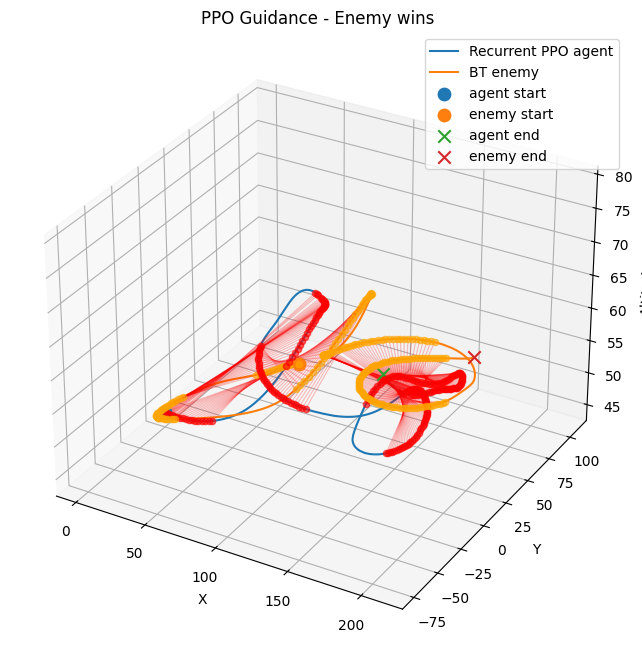

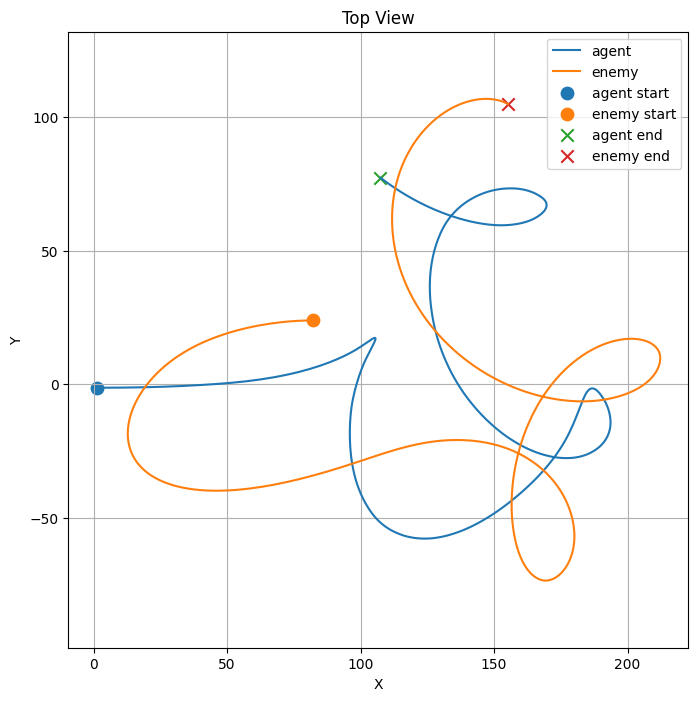

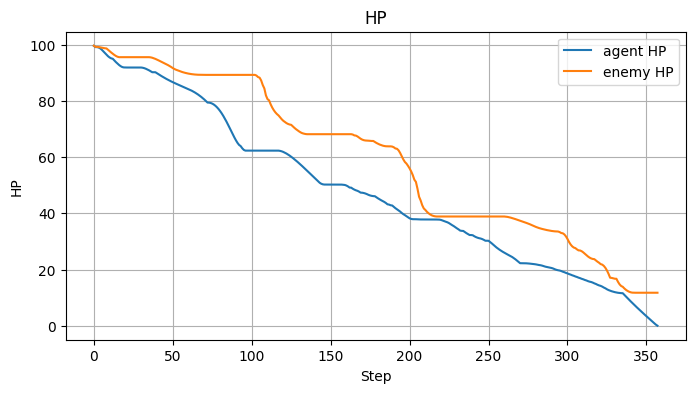

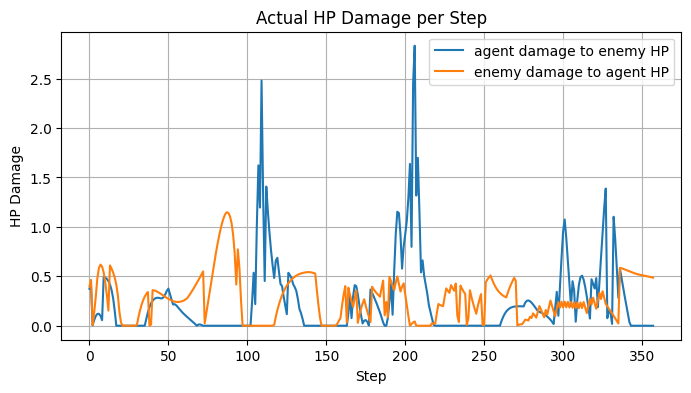

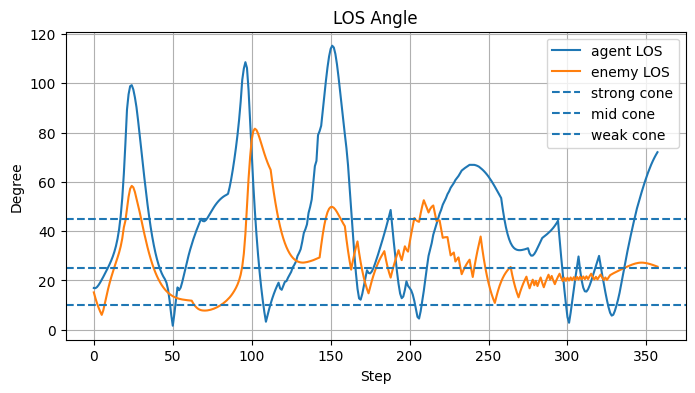

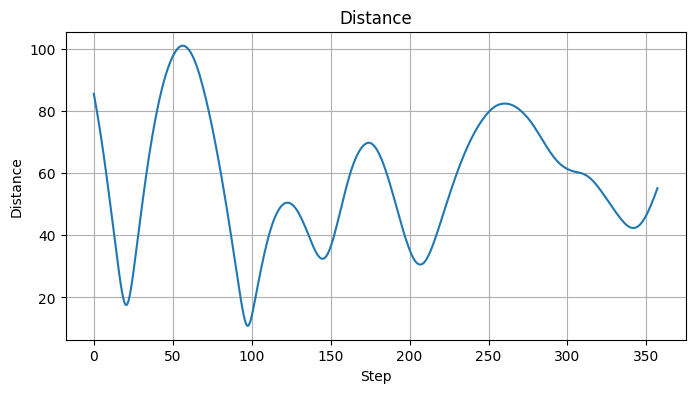

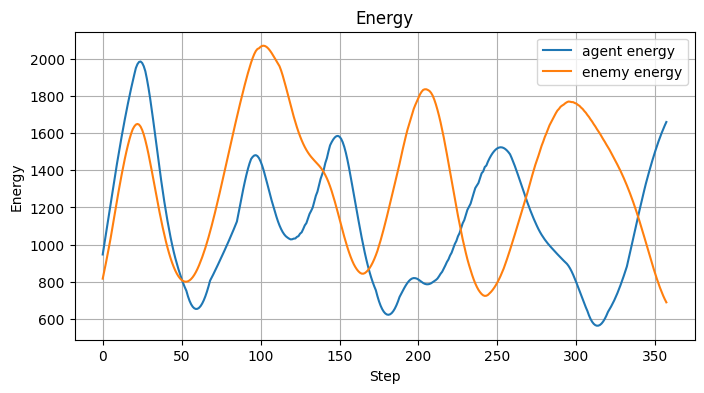

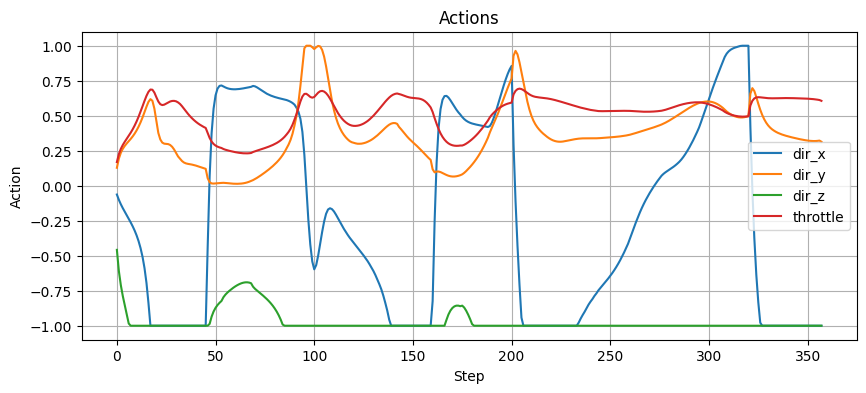

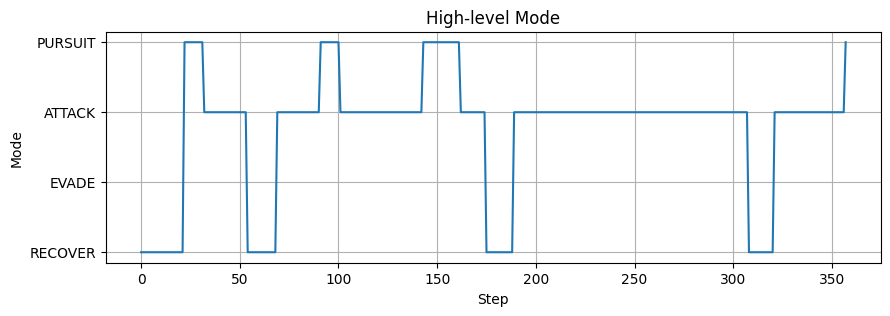

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sb3_contrib import RecurrentPPO
from src.direct_guidance_fighter_env import DirectGuidanceFighterEnv


MODE_NAMES = {
    0: "RECOVER",
    1: "EVADE",
    2: "ATTACK",
    3: "PURSUIT",
}

MAX_COMBAT_STEPS = 10_000
DETERMINISTIC = True

env = DirectGuidanceFighterEnv()
env.max_steps = 10**12

model = RecurrentPPO.load("models/recurrent_ppo_direct_guidance")

obs, _ = env.reset()

lstm_states = None
episode_starts = np.ones((1,), dtype=bool)

agent_traj = []
enemy_traj = []
modes = []
actions = []

agent_hp = []
enemy_hp = []

agent_damage_rate = []
enemy_damage_rate = []
agent_damage_to_hp = []
enemy_damage_to_hp = []

agent_los = []
enemy_los = []
dists = []
agent_energy = []
enemy_energy = []
rewards = []

firing_events = []

winner = None

for step in range(MAX_COMBAT_STEPS):
    action, lstm_states = model.predict(
        obs,
        state=lstm_states,
        episode_start=episode_starts,
        deterministic=DETERMINISTIC,
    )

    obs, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated
    episode_starts = np.array([done], dtype=bool)

    agent_traj.append(info["agent_pos"])
    enemy_traj.append(info["enemy_pos"])
    modes.append(info["mode"])
    actions.append(action.copy())

    agent_hp.append(info["agent_hp"])
    enemy_hp.append(info["enemy_hp"])

    agent_damage_rate.append(info["agent_damage_rate"])
    enemy_damage_rate.append(info["enemy_damage_rate"])
    agent_damage_to_hp.append(info["agent_damage_to_hp"])
    enemy_damage_to_hp.append(info["enemy_damage_to_hp"])

    agent_los.append(info["agent_los_deg"])
    enemy_los.append(info["enemy_los_deg"])

    dists.append(info["dist"])
    agent_energy.append(info["agent_energy"])
    enemy_energy.append(info["enemy_energy"])
    rewards.append(reward)

    if info["agent_damage_to_hp"] > 0.0:
        firing_events.append({
            "agent_pos": info["agent_pos"].copy(),
            "enemy_pos": info["enemy_pos"].copy(),
            "damage": info["agent_damage_to_hp"],
        })

    if info["enemy_hp"] <= 0.0:
        winner = "Agent wins"
        print(f"{winner} at step {step}")
        break

    if info["agent_hp"] <= 0.0:
        winner = "Enemy wins"
        print(f"{winner} at step {step}")
        break

    if info["agent_altitude"] < info["min_combat_altitude"]:
        winner = "Agent crashed / below combat altitude"
        print(f"{winner} at step {step}")
        break

    if info["enemy_altitude"] < info["min_combat_altitude"]:
        winner = "Enemy crashed / below combat altitude"
        print(f"{winner} at step {step}")
        break

else:
    winner = "No winner"
    print(f"{winner} after {MAX_COMBAT_STEPS} steps")


agent_traj = np.array(agent_traj)
enemy_traj = np.array(enemy_traj)
modes = np.array(modes)
actions = np.array(actions)


print("\n========== Combat Summary ==========")
print("winner:", winner)
print("steps:", len(agent_traj))
print("final agent hp:", agent_hp[-1])
print("final enemy hp:", enemy_hp[-1])
print("min agent altitude:", np.min(agent_traj[:, 2]))
print("min enemy altitude:", np.min(enemy_traj[:, 2]))
print("min dist:", np.min(dists))
print("final dist:", dists[-1])
print("min agent LOS:", np.min(agent_los))
print("min enemy LOS:", np.min(enemy_los))
print("max agent damage to HP:", np.max(agent_damage_to_hp))
print("max enemy damage to HP:", np.max(enemy_damage_to_hp))
print("total agent HP damage:", np.sum(agent_damage_to_hp))
print("total enemy HP damage:", np.sum(enemy_damage_to_hp))
print("total reward:", np.sum(rewards))
print("firing event count:", len(firing_events))

print("\n========== Mode Count ==========")
for mode_id, count in Counter(modes).items():
    print(f"{MODE_NAMES[mode_id]:8s}: {count}")

print("\n========== Action Stats ==========")
print("action mean [dir_x, dir_y, dir_z, throttle]:", actions.mean(axis=0))
print("action std  [dir_x, dir_y, dir_z, throttle]:", actions.std(axis=0))


# =========================
# 3D Plot
# =========================
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(agent_traj[:, 0], agent_traj[:, 1], agent_traj[:, 2], label="Recurrent PPO agent")
ax.plot(enemy_traj[:, 0], enemy_traj[:, 1], enemy_traj[:, 2], label="BT enemy")

ax.scatter(agent_traj[0, 0], agent_traj[0, 1], agent_traj[0, 2], s=80, label="agent start")
ax.scatter(enemy_traj[0, 0], enemy_traj[0, 1], enemy_traj[0, 2], s=80, label="enemy start")

ax.scatter(agent_traj[-1, 0], agent_traj[-1, 1], agent_traj[-1, 2], s=80, marker="x", label="agent end")
ax.scatter(enemy_traj[-1, 0], enemy_traj[-1, 1], enemy_traj[-1, 2], s=80, marker="x", label="enemy end")

# firing visualization
for event in firing_events[::max(1, len(firing_events) // 200)]:
    ap = event["agent_pos"]
    ep = event["enemy_pos"]

    ax.scatter(ap[0], ap[1], ap[2], s=20, c="red", alpha=0.6)
    ax.scatter(ep[0], ep[1], ep[2], s=20, c="orange", alpha=0.6)
    ax.plot(
        [ap[0], ep[0]],
        [ap[1], ep[1]],
        [ap[2], ep[2]],
        color="red",
        linewidth=0.8,
        alpha=0.25,
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Altitude")
ax.set_title(f"PPO Guidance - {winner}")
ax.legend()
plt.show()


# =========================
# Top View
# =========================
plt.figure(figsize=(8, 8))
plt.plot(agent_traj[:, 0], agent_traj[:, 1], label="agent")
plt.plot(enemy_traj[:, 0], enemy_traj[:, 1], label="enemy")

plt.scatter(agent_traj[0, 0], agent_traj[0, 1], s=80, label="agent start")
plt.scatter(enemy_traj[0, 0], enemy_traj[0, 1], s=80, label="enemy start")

plt.scatter(agent_traj[-1, 0], agent_traj[-1, 1], s=80, marker="x", label="agent end")
plt.scatter(enemy_traj[-1, 0], enemy_traj[-1, 1], s=80, marker="x", label="enemy end")

plt.title("Top View")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# HP
# =========================
plt.figure(figsize=(8, 4))
plt.plot(agent_hp, label="agent HP")
plt.plot(enemy_hp, label="enemy HP")
plt.title("HP")
plt.xlabel("Step")
plt.ylabel("HP")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# Actual HP Damage
# =========================
plt.figure(figsize=(8, 4))
plt.plot(agent_damage_to_hp, label="agent damage to enemy HP")
plt.plot(enemy_damage_to_hp, label="enemy damage to agent HP")
plt.title("Actual HP Damage per Step")
plt.xlabel("Step")
plt.ylabel("HP Damage")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# LOS
# =========================
plt.figure(figsize=(8, 4))
plt.plot(agent_los, label="agent LOS")
plt.plot(enemy_los, label="enemy LOS")
plt.axhline(10.0, linestyle="--", label="strong cone")
plt.axhline(25.0, linestyle="--", label="mid cone")
plt.axhline(45.0, linestyle="--", label="weak cone")
plt.title("LOS Angle")
plt.xlabel("Step")
plt.ylabel("Degree")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# Distance
# =========================
plt.figure(figsize=(8, 4))
plt.plot(dists)
plt.title("Distance")
plt.xlabel("Step")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


# =========================
# Energy
# =========================
plt.figure(figsize=(8, 4))
plt.plot(agent_energy, label="agent energy")
plt.plot(enemy_energy, label="enemy energy")
plt.title("Energy")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# Actions
# =========================
plt.figure(figsize=(10, 4))
plt.plot(actions[:, 0], label="dir_x")
plt.plot(actions[:, 1], label="dir_y")
plt.plot(actions[:, 2], label="dir_z")
plt.plot(actions[:, 3], label="throttle")
plt.title("Actions")
plt.xlabel("Step")
plt.ylabel("Action")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# Mode
# =========================
plt.figure(figsize=(10, 3))
plt.plot(modes)
plt.yticks([0, 1, 2, 3], ["RECOVER", "EVADE", "ATTACK", "PURSUIT"])
plt.title("High-level Mode")
plt.xlabel("Step")
plt.ylabel("Mode")
plt.grid(True)
plt.show()